### Básicos

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from astropy.io import fits

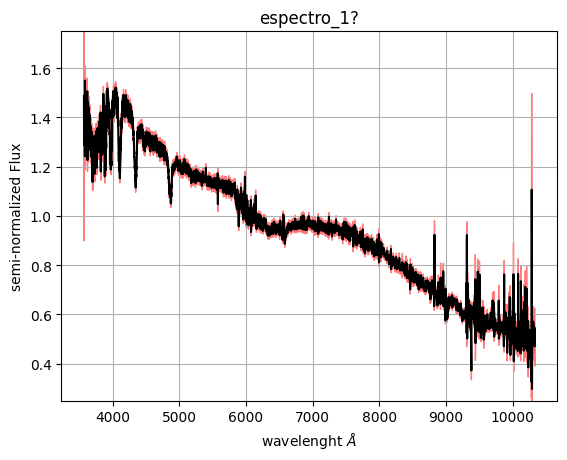

In [2]:
hdu= fits.open('sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits')

dat= hdu['COADD'].data
flux= dat['flux']
flux_norm= dat['flux']/np.median(dat['flux'])  
wavelength= 10**dat['loglam']


ivar= dat['ivar']
good_pixels= ivar>0  #máscara para eliminar los valores malos 
noise= np.zeros_like(ivar)
noise[good_pixels]= np.sqrt(1/ivar[good_pixels])

noise[~good_pixels]= np.nan
noise_norm= noise/ np.median(dat['flux'])



plt.fill_between(wavelength, flux_norm - noise_norm, flux_norm + noise_norm, 
                 color='red', alpha=0.5, label='Error (Ruido)')


plt.plot(wavelength,flux_norm, color='black')
plt.title('espectro_1?')
plt.xlabel(r'wavelenght $\AA$ ')
plt.ylabel('semi-normalized Flux')
plt.grid('on')
plt.ylim(0.25,1.75)
plt.show()

In [32]:
hdu[2].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 4016 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                  236 / number of table fields                         
EXTNAME = 'SPALL   '           / extension name                                 
TTYPE1  = 'PROGRAMNAME'                                                         
TFORM1  = '27A     '                                                            
TTYPE2  = 'CHUNK   '                                                            
TFORM2  = '14A     '        

In [3]:
hdu.info()

Filename: sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     148   ()      
  1  COADD         1 BinTableHDU     26   4619R x 8C   ['E', 'E', 'E', 'J', 'J', 'E', 'E', 'E']   
  2  SPALL         1 BinTableHDU    488   1R x 236C   [27A, 14A, 4A, E, E, J, J, E, J, E, E, E, K, K, K, K, K, K, K, K, K, B, B, J, I, 5E, 5E, J, J, J, J, 7A, 7A, 16A, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, 5E, E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 16A, 9A, 12A, E, E, E, E, E, E, E, E, J, E, E, J, J, 6A, 21A, E, 35E, K, 19A, 19A, 19A, B, B, B, I, 3A, B, I, I, I, I, J, E, J, J, E, E, E, E, E, E, E, E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5J, 5J, 5J, 5E, 5J, 75E, 75E, 5E, 5E, 5E, 5J, 5E, D, D, D, D, D, D, D, D, D, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5

###  Ejemplo usando specutils

        Use Spectrum instead. [warnings]
    The maximum number of function evaluations is exceeded. [astropy.modeling.fitting]


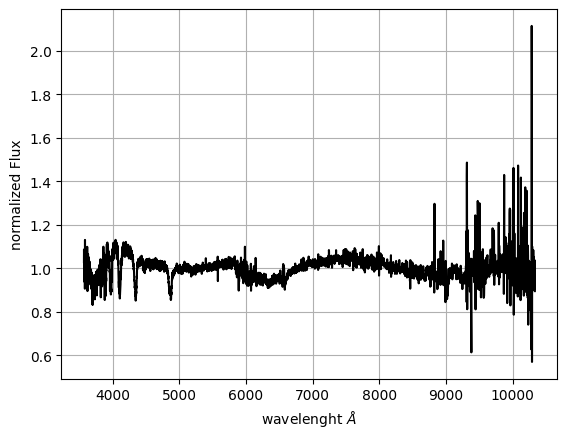

In [4]:
# ajuste usando las librerias de forma directa
from specutils import Spectrum1D
from specutils.fitting import fit_continuum
from astropy.modeling import models
import astropy.units as u


# creamos el objeto del espectro dandole las unidades a al flujo y la wavelength
spec= Spectrum1D(spectral_axis= wavelength*u.AA, flux= flux * u.Unit('erg cm-2 s-1 AA-1'))

#ajustamos el continuo; podríamos excluir rgiones (exclude_regions) y darle una ventana específica (window)
continuum_model= fit_continuum(spec, model=models.Chebyshev1D(degree=6) )
continuum_flux= continuum_model(wavelength * u.AA).value

normalized_spec= flux/ continuum_flux

plt.plot(wavelength, normalized_spec, color= 'black')
#plt.plot(wavelength, flux, color= 'black')
#plt.plot(wavelength,continuum_flux,color='red', alpha= 0.6)
plt.xlabel(r'wavelenght $\AA$ ')
plt.ylabel('normalized Flux')
plt.grid('on')
plt.show()


In [5]:
#si lo hacemos utilizando numpy 
def fit_spec(wavelength,flux, degree, sigma, iter):
    """Con esta función normalizamos haciendo sigma clipping para eliminar ruido y
    obtener el continuo de forma limpia
    Si no se dan todos los parámetros se toman:
    - 5 iteraciones para sigma clipping por defecto 
    - un grado de 5 como máximo
    - una tolerancia de 2 sigma
    """
    polynomials = []
    MSEs = []

    for grade in range(1, degree+1):
        
        mask = np.ones(len(flux), dtype=bool)
        
        for i in range(iter+1):
        
            model = np.poly1d(np.polyfit( wavelength[mask], flux[mask], grade))
            # Calculamos residuos y re-evaluamos la máscara
            residuals = flux - model(wavelength)
            std_val = np.std(residuals[mask]) # Desviación del continuo     
            new_mask = np.abs(residuals) < (sigma * std_val)
            if np.array_equal(mask, new_mask):
                    break # Paramos si converge antes de las itercaiones dadas
            mask = new_mask
            
        mse = np.sqrt( (1/len(flux[mask])) * np.sum( (flux[mask] - model(wavelength[mask])) ** 2) )
        polynomials.append(model)
        MSEs.append(mse)

    index = np.argmin(MSEs)
    best_model = polynomials[index]
    return best_model
    
    
def plot_spec(best_model,wave,flux):

    #Generamos el array del continuo
    continuum_flux = best_model(wave)
    #Normalizamos
    flux_normalized = flux / continuum_flux

# --- GRAFICAR ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # --- PANEL IZQUIERDO (Original + Ajuste) ---
    # Usamos ax1 en lugar de plt
    ax1.plot(wave, flux, color='black', label='Flux')
    ax1.plot(wave, continuum_flux, color='red', lw=2, label='Best Fit')
    
    ax1.set_title("Ajuste del Continuo")
    ax1.set_xlabel(r'Wavelength $\AA$')
    ax1.set_ylabel('Flux (Original Units)')
    ax1.grid('on')
    ax1.legend()

    
    # Usamos ax2
    ax2.plot(wave, flux_normalized, color='black', lw=0.8, label='Normalized Flux')
    
    # Añadimos una línea guía en 1.0 (El estándar científico)
    ax2.axhline(1.0, color='red', linestyle='--', lw=1.5, label='Continuum Level')
    
    ax2.set_title("Espectro Normalizado")
    ax2.set_xlabel(r'Wavelength $\AA$')
    ax2.set_ylabel('Normalized Flux')
    ax2.grid('on')
    ax2.legend()

    # Ajusta automáticamente los espacios para que no se superpongan etiquetas
    plt.tight_layout()
    plt.show()
    

C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\4213713021.py:19: RankWarning: Polyfit may be poorly conditioned
  model = np.poly1d(np.polyfit( wavelength[mask], flux[mask], grade))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\4213713021.py:19: RankWarning: Polyfit may be poorly conditioned
  model = np.poly1d(np.polyfit( wavelength[mask], flux[mask], grade))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\4213713021.py:19: RankWarning: Polyfit may be poorly conditioned
  model = np.poly1d(np.polyfit( wavelength[mask], flux[mask], grade))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\4213713021.py:19: RankWarning: Polyfit may be poorly conditioned
  model = np.poly1d(np.polyfit( wavelength[mask], flux[mask], grade))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\4213713021.py:19: RankWarning: Polyfit may be poorly conditioned
  model = np.poly1d(np.polyfit( wavelength[mask], flux[mask], grade))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\4213713021.py:19: RankWarning: 

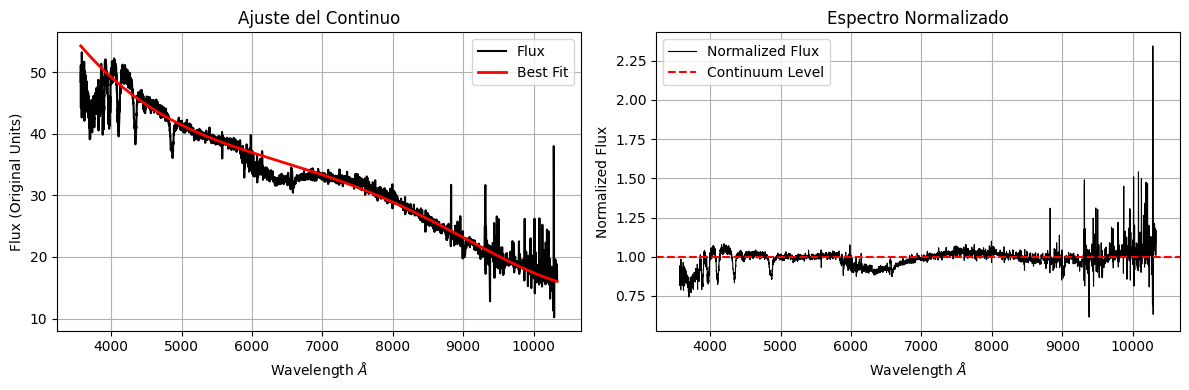

In [6]:
model= fit_spec(wavelength,flux, 5,2,8)
plot_spec(model,wavelength,flux)

### Función para abrir los archivos

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import os

def open_single_spectrum(filename):
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.
    """
    try:
        with fits.open(filename) as hdu:
            dat = hdu['COADD'].data
            header = hdu[0].header
            
            # Extracción de variables
            flux = dat['flux']
            wavelength = 10**dat['loglam']
            ivar = dat['ivar']
            
            # Cálculo de ruido 
            good_pixels = ivar > 0 
            noise = np.zeros_like(ivar)
            noise[good_pixels] = np.sqrt(1 / ivar[good_pixels])
            noise[~good_pixels] = np.nan
            
            # Normalización del ruido
            noise_norm = noise / np.median(flux)
            return {
                "filename": os.path.basename(filename),
                "wavelength": wavelength,
                "flux": flux,
                "noise_norm": noise_norm,
                "header": header,
                "ivar": ivar
            }
            
    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        return None


def load_all_spectra(folder_path):
    
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.
    Ejemplo de uso
    base_de_datos = load_all_spectra(carpeta_datos)
    y para acceder al primer espectro cargado:
    primer_espectro = base_de_datos[0]
    """
    search_pattern = os.path.join(folder_path, "*.fits") 
    
    #Lista con todos los archivos que coincidan con *.fits
    fits_files = glob.glob(search_pattern)
    
    print(f"Se encontraron {len(fits_files)} archivos espectrales.")
    
    spectra_database = []
    
    for file in fits_files:
        data = open_single_spectrum(file)
        if data is not None:
            spectra_database.append(data)
            
    return spectra_database


In [8]:
help(load_all_spectra)

Help on function load_all_spectra in module __main__:

load_all_spectra(folder_path)
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.
    Ejemplo de uso
    base_de_datos = load_all_spectra(carpeta_datos)
    y para acceder al primer espectro cargado:
    primer_espectro = base_de_datos[0]



Se encontraron 43 archivos espectrales.


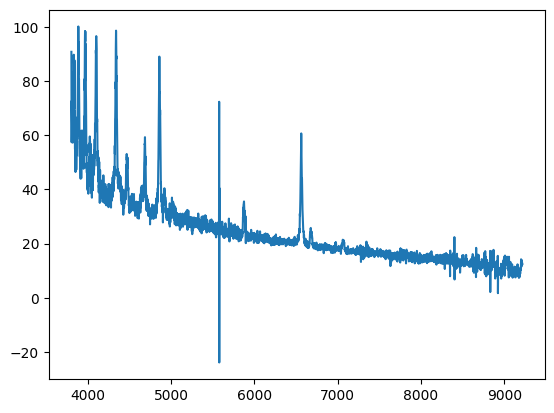

In [9]:
carpeta_datos = 'sdss_specs' 
base_de_datos = load_all_spectra(carpeta_datos)

espectro1= base_de_datos[22]   # el espectro 2 ==> 3 es qel que parece estar malo
plt.plot(espectro1['wavelength'], espectro1['flux'])


### Función para recortar los bordes muy ruidosos de los espectros

In [10]:
import numpy as np
from scipy.ndimage import median_filter

def plot_cut_spec(wavelength, flux, ivar, snr_threshold=3, window_size=21):
    """
    Encuentra los índices de inicio y fin para recortar un espectro basado en S/N.
    
    Parámetros:
        flux (array): Flujo del espectro.
        ivar (array): Varianza inversa (Inverse Variance).
        snr_threshold (float): S/N mínimo aceptable (Estándar: 3.0 para detección fiable).
        window_size (int): Tamaño de la ventana de suavizado, el cual debe ser impar. Para este caso se toma 21. 
                         
    
    Retorna:
        start_idx, end_idx (int): Índices sugeridos para el recorte.
    """
    
    #Calculamos S/N 
    good_pixels= ivar>0  #máscara para eliminar los valores malos 
    noise= np.zeros_like(ivar)
    noise[good_pixels]= np.sqrt(1/ivar[good_pixels])
    noise[~good_pixels]= np.nan

    snr = flux / noise
        
    # Limpiamos NaNs e Infinitos que resulten de dividir por cero
    snr = np.nan_to_num(snr, nan=0.0, posinf=0.0, neginf=0.0)
    
    # sigue suavizar el S/N 
    # El filtro de mediana ignora picos de ruido aislados pero respeta estructuras anchas (líneas)
    snr_smooth = median_filter(snr, size=window_size)
    
    # Creamos la máscara y encotramos los bordes
    is_good = snr_smooth > snr_threshold
    good_indices = np.where(is_good)[0]
    
    # Tomamos el primero y el último índice bueno
    start_idx = good_indices[0]
    end_idx = good_indices[-1]
    
    # Margen de seguridad (opcional): Retroceder unos píxeles para no cortar abruptamente
    # padding = window_size // 2
    # start_idx = max(0, start_idx - padding)
    # end_idx = min(len(flux), end_idx + padding)
    
    flux_recortado = flux[start_idx:end_idx]
    wave_recortado = wavelength[start_idx:end_idx]
    
        # Graficar
    #plt.figure(figsize=(7, 5))
    #plt.plot(wave_recortado, flux_recortado, color='black', label='Flux')
    #plt.plot(wavelength, continuum_flux, color='red', lw=2, label='best fit')
    #plt.title("Spectro n??")
    #plt.xlabel(r'wavelenght $\AA$ ')
    #plt.ylabel(r'Flux $(ergs\,s^{-1}\,cm^{-2}\,\AA)$')
    #plt.axvline(6562.8,color='red',ls='dashed',alpha=0.7)
    #plt.grid('on')
    #plt.legend()
    #plt.show()
    
    return wave_recortado, flux_recortado

# ejemplo de uso:
wave,fx  =plot_cut_spec(wavelength, flux, ivar, snr_threshold=30)



In [11]:
wave,fx = plot_cut_spec(espectro1['wavelength'],espectro1['flux'], espectro1['ivar'], snr_threshold=12)
#poner el treshold (trabajar en definir threshold que se adapte automático) 


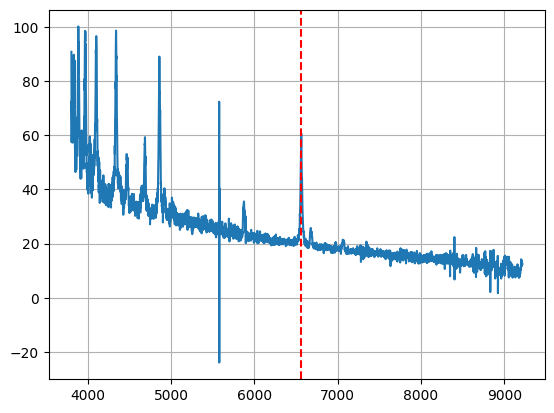

In [12]:
plt.plot(espectro1['wavelength'],espectro1['flux'])
plt.axvline(6562,color='red',ls= 'dashed')
plt.grid('on')

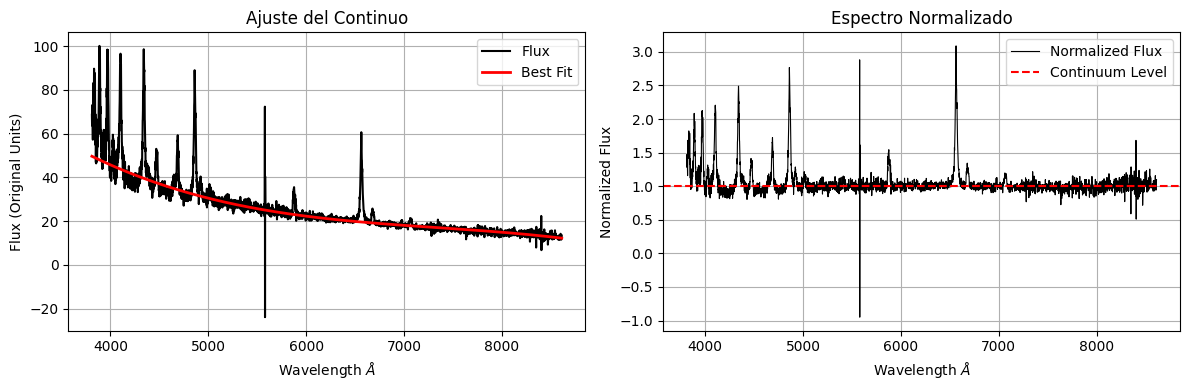

In [13]:
model= fit_spec(wave,fx , 3,2,8)
plot_spec(model,wave,fx)

In [14]:
carpeta_datos = 'sdss_specs' 
base_de_datos = load_all_spectra(carpeta_datos)
espectro_n= base_de_datos[22]
wave,fx= plot_cut_spec(espectro_n['wavelength'],espectro_n['flux'],espectro_n['ivar'],snr_threshold=4)

Se encontraron 43 archivos espectrales.


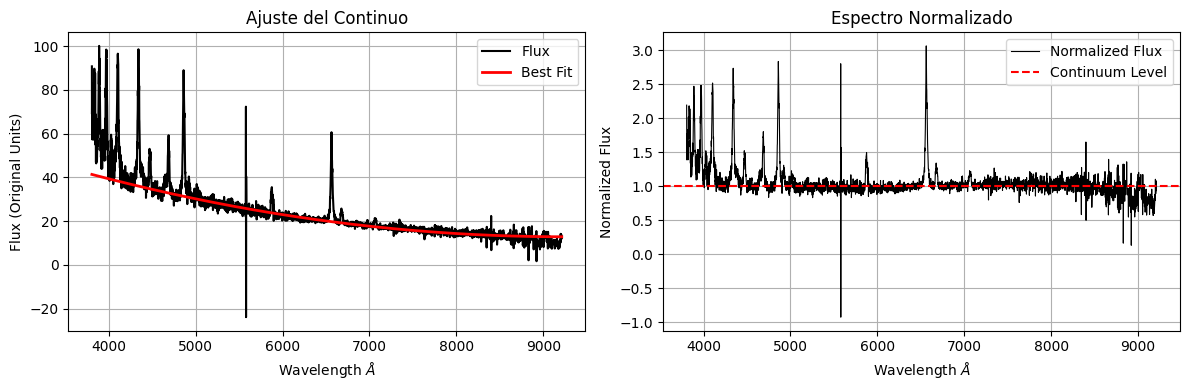

In [15]:
model= fit_spec(wave,fx , 2,2,8)
plot_spec(model,wave,fx)

### Añadir el enmascaramiento a las líneas de emisión

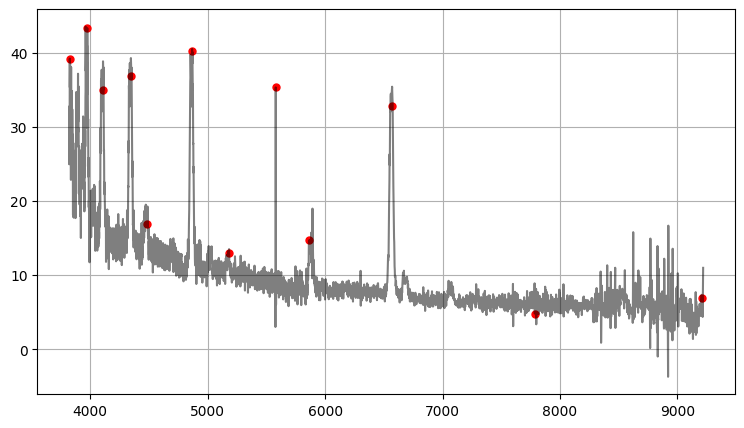

In [16]:
# find_peaks_ctw continuum wavelet transform hace convoluciones con una especie de campana que se desplaza alrededor de la señal
# tiene como ventaja ser muy robusto y despreciar ruido de forma efectiva, sin embargo es un poco más lento

espectro_n= base_de_datos[11]
from scipy.signal import find_peaks_cwt, peak_widths  #del repositorio: https://github.com/btjones-me/raman_spectroscopy/blob/master/Raman%20Spectroscopy/PythonCode/raman_analysis_clean.py
def find_peaks_scipy(xs, ys, widths=np.arange(5,50, 0.5)):

    peaks = find_peaks_cwt(ys, widths, min_snr= 2)
    plt.figure(figsize=(9,5))
    plt.plot(xs[peaks], ys[peaks], marker='o', linestyle='', markersize='5',color='red')
    plt.plot(xs,ys,color='black',alpha=0.5)
    plt.grid('on')
    
    return peaks


x= espectro_n['wavelength']
y= espectro_n['flux']
peaks= find_peaks_scipy(x,y)


#plt.plot(x[peaks], y[peaks], marker='+', linestyle='', markersize='12')
#plt.plot(x,y,color='black')


[3825.604  3843.263  3895.83   3939.128  3960.956  3974.6592 4032.739
 4097.321  4108.657  4346.102  4487.4536 4854.0024 4867.4326 5869.485
 6570.524 ]


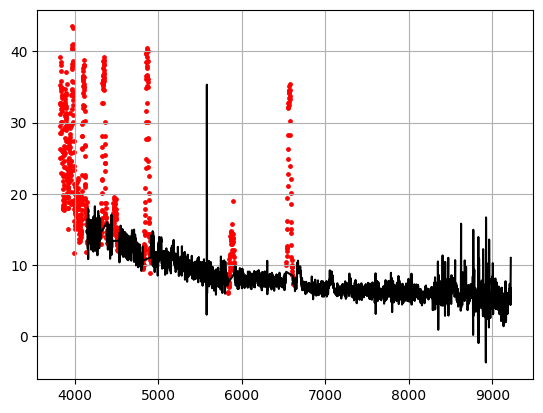

In [17]:

from scipy.signal import find_peaks   
from scipy.ndimage import median_filter
import numpy as np

def get_mask(wavelength, flux, sigma=1, width_mask=40):
    flux_clean = flux.astype(float)
    continuum_rough = median_filter(flux_clean, size=101)
    flattened = flux - continuum_rough
    noise_level = np.std(flattened)
    
    peaks, properties = find_peaks(flattened, height=sigma*noise_level, width=5)
    
    mask = np.ones(len(wavelength), dtype=bool)
    
    for peak_idx in peaks:
        center_wave = wavelength[peak_idx]
        bad_region = (wavelength > center_wave - width_mask) & \
                     (wavelength < center_wave + width_mask)
        mask[bad_region] = False
        

    return mask, peaks

mask, peaks= get_mask(x,y)
plt.scatter(x[~mask],y[~mask],color='red',s=6)
plt.plot(x[mask],y[mask],color='black')
#plt.plot(x,y-1,color='blue',alpha=0.6)
plt.grid('on')
print(x[peaks])

C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\1507388405.py:31: PeakPropertyWarning: some peaks have a prominence of 0
  prominences, left_bases, right_bases = peak_prominences(y, peaks)
C:\Users\paisa\AppData\Local\Temp\ipykernel_6768\1507388405.py:32: PeakPropertyWarning: some peaks have a width of 0
  widths_pixels,_,_,_= peak_widths(y,peaks,rel_height=0.5, prominence_data=(prominences, left_bases, right_bases)) # al dar rel_hight=0.5 nos da la FWHM


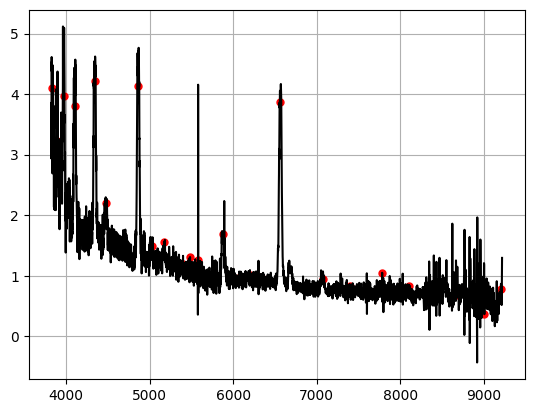

In [18]:
#borrador para enmáscarar
from scipy.signal import find_peaks_cwt, peak_widths, peak_prominences
def mask_em_lines(x, y, widths=np.arange(10,50, 0.5)):

    peaks = find_peaks_cwt(y, widths, min_snr= 1)
    
    #plt.plot(xs[peaks], ys[peaks], marker='o', linestyle='', markersize='5',color='red')
    #plt.plot(xs,ys,color='black')
    #plt.grid('on')
    
    #Dic con las líneas (requiere tener importado astropy.units as u)
    
    lines= {
    'H_alpha': 6562.8 * u.AA,
    'H_beta': 4861.3 * u.AA,
    'H_gamma': 4340.5 * u.AA,
    'H_delta': 4101.7 * u.AA,
    'H_epsilon': 3970.1 * u.AA,
    'H_zeta': 3889.1 * u.AA,
    'H_eta': 3835.4 * u.AA,
    'HeI_4471': 4471.5 * u.AA,
    'HeI_4713': 4713.4 * u.AA,
    'HeI_4921': 4921.9 * u.AA,
    'HeI_5015': 5015.7 * u.AA,
    'HeI_5875': 5875.7 * u.AA,
    'HeI_6678': 6678.2 * u.AA,
    'HeI_7065': 7065.2 * u.AA,
    'HeII_4686': 4685.7 * u.AA,
    'HeII_5411': 5411.5 * u.AA
    }
    prominences, left_bases, right_bases = peak_prominences(y, peaks)
    widths_pixels,_,_,_= peak_widths(y,peaks,rel_height=0.5, prominence_data=(prominences, left_bases, right_bases)) # al dar rel_hight=0.5 nos da la FWHM
    
    continuum_mask = np.ones(len(x), dtype=bool)
    treshold= 10 #dejamos un rango de +-10 pixeles de tolerancia
    fwhm= []
    for peak_i, width_px in zip(peaks,widths_pixels):
        obs_wave= x[peak_i]
        dispersion = x[peak_i + 1] - x[peak_i] if peak_i < len(x)-1 else x[peak_i] - x[peak_i-1]
        fwhm_angstroms= width_px * dispersion
        fwhm.append(fwhm_angstroms)
        #ahora verificamos si esta línea coincide con las líneas esperadas que son las del diccionario
        found_match = False
        matched_name = ""
        
        for name, line in lines.items():
            if abs(obs_wave- line.value) < treshold:
                found_match = True
                matched_name = name
                break
            
        if found_match:                     # si hay match todo ok sólo sigue enmascarar 
            mask_radius= fwhm_angstroms*2   #tomamos el doble de FWHM como valor base (puede estar sobre estimado hay que ver)
            lines_region= (x > obs_wave - mask_radius) & (x < obs_wave + mask_radius)
            continuum_mask[lines_region] = False
            
            
    plt.plot(x[peaks], y[peaks], marker='o', linestyle='', markersize='5',color='red')
    plt.plot(x[continuum_mask], y[continuum_mask], color='black',ls='-')
    plt.grid('on')
    
    return peaks,fwhm




x= espectro_n['wavelength']
y= espectro_n['flux']/ np.median(espectro_n['flux'])
peaks, fwhm= mask_em_lines(x,y)


Líneas de emisión junto con bandas del continuo

self.lines = {
'H_alpha': 6562.8 * u.AA,
'H_beta': 4861.3 * u.AA,
'H_gamma': 4340.5 * u.AA,
'H_delta': 4101.7 * u.AA,
'H_epsilon': 3970.1 * u.AA,
'H_zeta': 3889.1 * u.AA,
'H_eta': 3835.4 * u.AA,
'HeI_4471': 4471.5 * u.AA,
'HeI_4713': 4713.4 * u.AA,
'HeI_4921': 4921.9 * u.AA,
'HeI_5015': 5015.7 * u.AA,
'HeI_5875': 5875.7 * u.AA,
'HeI_6678': 6678.2 * u.AA,
'HeI_7065': 7065.2 * u.AA,
'HeII_4686': 4685.7 * u.AA,
'HeII_5411': 5411.5 * u.AA
}


valor referencia para las bandas de 4MOST 
	392.6 – 435.5, 516 – 573, 610 – 679 nm

   BLUE GReen 5400      RED 6930- 9500 
   

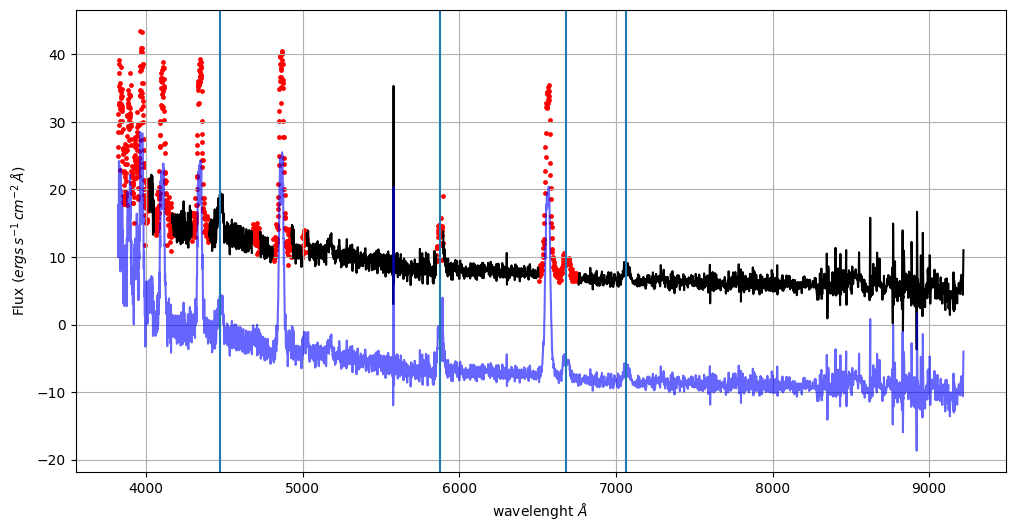

In [19]:
def mask_em_lines(wavelength, flux, sigma=3):
    
    flux_clean = flux.astype(float)
    continuum_rough = median_filter(flux_clean, size=101)
    flattened = flux - continuum_rough
    #noise_level = np.std(flattened)       esta  desviación engloba a los peaks más grandes y hace que se ignoren
                                           #las líneas más pequeñas, por eso mejor usamos la Desviación Absoluta de la Mediana MAD
    mad= np.median(np.abs(flattened - np.median(flattened)))
    noise_level= mad   #considerando un valor robusto para el ruido 
    peaks, properties = find_peaks(flattened, height= sigma*noise_level, width=3)
    widths_pixels,_,_,_= peak_widths(flattened ,peaks,rel_height=0.5)  # al dar rel_hight=0.5 nos da la FWHM
    #Dic con las líneas (requiere tener importado astropy.units as u)
    lines= {
    'H_alpha': 6562.8 * u.AA,
    'H_beta': 4861.3 * u.AA,
    'H_gamma': 4340.5 * u.AA,
    'H_delta': 4101.7 * u.AA,
    'H_epsilon': 3970.1 * u.AA,
    'H_zeta': 3889.1 * u.AA,
    'H_eta': 3835.4 * u.AA,
    'HeI_4471': 4471.5 * u.AA,
    'HeI_4713': 4713.4 * u.AA,
    'HeI_4921': 4921.9 * u.AA,
    'HeI_5015': 5015.7 * u.AA,
    'HeI_5875': 5875.7 * u.AA,
    'HeI_6678': 6678.2 * u.AA,
    'HeI_7065': 7065.2 * u.AA,
    'HeII_4686': 4685.7 * u.AA,
    'HeII_5411': 5411.5 * u.AA
    }
    
    mask = np.ones(len(wavelength), dtype=bool)
    treshold= 10 #dejamos un rango de +-10 pixeles de tolerancia
    fwhm= []
    for peak_i, width_px in zip(peaks,widths_pixels):
        obs_wave= wavelength[peak_i]
        dispersion = wavelength[peak_i + 1] - wavelength[peak_i] if peak_i < len(x)-1 else wavelength[peak_i] - wavelength[peak_i-1]
        fwhm_angstroms= width_px * dispersion
        fwhm.append(fwhm_angstroms)
        #ahora verificamos si esta línea coincide con las líneas esperadas que son las del diccionario
        found_match = False
        matched_name = ""
        
        for name, line in lines.items():
            if abs(obs_wave- line.value) < treshold:
                found_match = True
                matched_name = name
                break
        
        if found_match:                     # si hay match todo ok sólo sigue enmascarar 
            width_mask= fwhm_angstroms*1.8
            center_wave = wavelength[peak_i]
            bad_region = (wavelength > center_wave - width_mask) &  (wavelength < center_wave + width_mask)
            mask[bad_region] = False

    gaps_continuum= flux.copy()
    gaps_continuum[~mask]=np.nan
    
    plt.figure(figsize=(12,6))
    plt.scatter(wavelength[~mask], flux[~mask],color='red',s=6)
    plt.plot(wavelength, gaps_continuum,color='black')
    plt.plot(wavelength,flux-15,color='blue',alpha=0.6)
    plt.xlabel(r'wavelenght $\AA$ ')
    plt.ylabel(r'Flux $(ergs\,s^{-1}\,cm^{-2}\,\AA)$')
    plt.axvline(5875.7)
    plt.axvline(4471)
    plt.axvline(7065.2)
    plt.axvline(6678.2)
    plt.grid('on')

    return mask, fwhm

x= espectro_n['wavelength']
y= espectro_n['flux']
mask, fwhm= mask_em_lines(x,y)

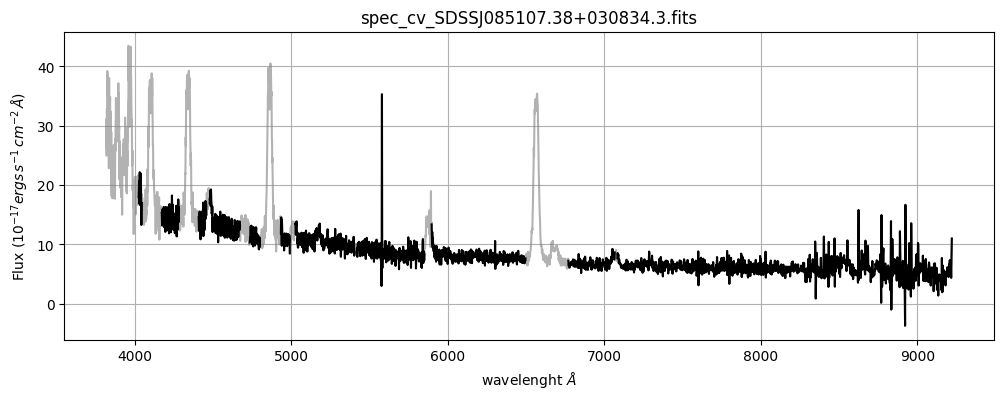

In [20]:
def mask_em_lines(espectro, sigma=1):
    
    wavelength= espectro['wavelength']
    flux= espectro['flux']
    filename= espectro['filename']
    
    flux_clean = flux.astype(float)
    continuum_rough = median_filter(flux_clean, size=101)
    flattened = flux - continuum_rough
    #noise_level = np.std(flattened)       esta  desviación engloba a los peaks más grandes y hace que se ignoren
                                           #las líneas más pequeñas, por eso mejor usamos la Desviación Absoluta de la Mediana MAD
    mad= np.median(np.abs(flattened - np.median(flattened)))
    noise_level= mad*1.4826   #considerando un valor robusto para el ruido 
    peaks, properties = find_peaks(flattened,prominence= sigma*noise_level, width=2)
    widths_pixels,_,_,_= peak_widths(flattened , peaks, rel_height=0.5, prominence_data=(properties['prominences'], 
                                                          properties['left_bases'], 
                                                          properties['right_bases']))  # esta vez usando prominences en vez de height
    #Dic con las líneas (requiere tener importado astropy.units as u)
    lines= {
    'H_alpha': 6562.8 * u.AA,
    'H_beta': 4861.3 * u.AA,
    'H_gamma': 4340.5 * u.AA,
    'H_delta': 4101.7 * u.AA,
    'H_epsilon': 3970.1 * u.AA,
    'H_zeta': 3889.1 * u.AA,
    'H_eta': 3835.4 * u.AA,
    'HeI_4471': 4471.5 * u.AA,
    'HeI_4713': 4713.4 * u.AA,
    'HeI_4921': 4921.9 * u.AA,
    'HeI_5015': 5015.7 * u.AA,
    'HeI_5875': 5875.7 * u.AA,
    'HeI_6678': 6678.2 * u.AA,
    'HeI_7065': 7065.2 * u.AA,
    'HeII_4686': 4685.7 * u.AA,
    'HeII_5411': 5411.5 * u.AA
    }
    
    mask = np.ones(len(wavelength), dtype=bool)
    treshold= 10 #dejamos un rango de +-10 pixeles de tolerancia
    fwhm= []
    for peak_i, width_px in zip(peaks,widths_pixels):
        obs_wave= wavelength[peak_i]
        dispersion = wavelength[peak_i + 1] - wavelength[peak_i] if peak_i < len(x)-1 else wavelength[peak_i] - wavelength[peak_i-1]
        fwhm_angstroms= width_px * dispersion
        fwhm.append(fwhm_angstroms)
        #ahora verificamos si esta línea coincide con las líneas esperadas que son las del diccionario
        found_match = False
        matched_name = ""
        
        for name, line in lines.items():
            if abs(obs_wave- line.value) < treshold:
                found_match = True
                matched_name = name
                break
        
        if found_match:                     # si hay match todo ok sólo sigue enmascarar 
            width_mask= fwhm_angstroms*2
            center_wave = wavelength[peak_i]
            bad_region = (wavelength > center_wave - width_mask) &  (wavelength < center_wave + width_mask)
            mask[bad_region] = False

    gaps_continuum= flux.copy()
    gaps_continuum[~mask]=np.nan
    continuum= flux[mask]
    
    plt.figure(figsize=(12,4))
    plt.title(filename)
    #plt.scatter(wavelength[~mask], flux[~mask],color='red',s=6)
    plt.plot(wavelength, flux, color='grey',alpha=0.6)
    plt.plot(wavelength, gaps_continuum,color='black')
    plt.xlabel(r'wavelenght $\AA$ ')
    plt.ylabel(r'Flux $(10^{-17}ergs\,s^{-1}\,cm^{-2}\,\AA)$')
    #plt.axvline(5580)
    #plt.axvline(5875.7)
    #plt.axvline(4471)
    #plt.axvline(7065.2)
    #plt.axvline(6678.2)
    #plt.axvline(6562.8)
    plt.grid('on')

    return continuum, mask, fwhm

#x= espectro_n['wavelength']
#y= espectro_n['flux']
continuum, mask, fwhm= mask_em_lines(espectro_n,sigma=1)

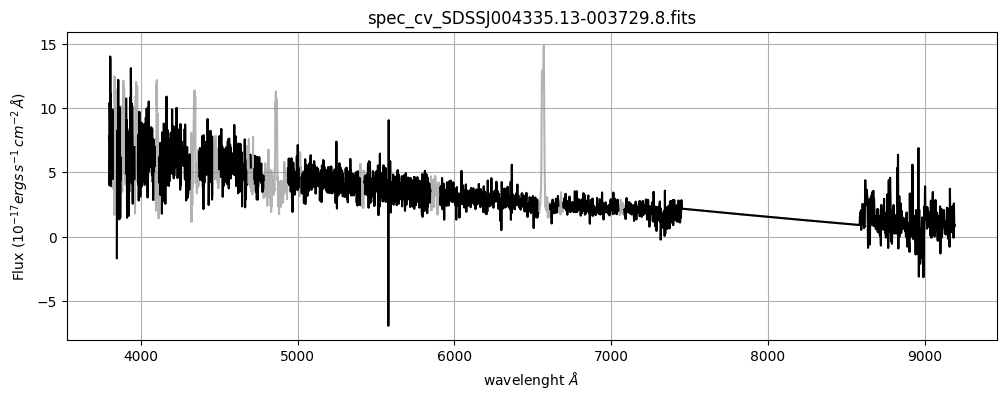

In [21]:
espectro_x= base_de_datos[2]        #problema espectro 7, lo mismo el 8
#x2= espectro_x['wavelength']
#y2= espectro_x['flux']

continuum, mask, fwhm= mask_em_lines(espectro_x)

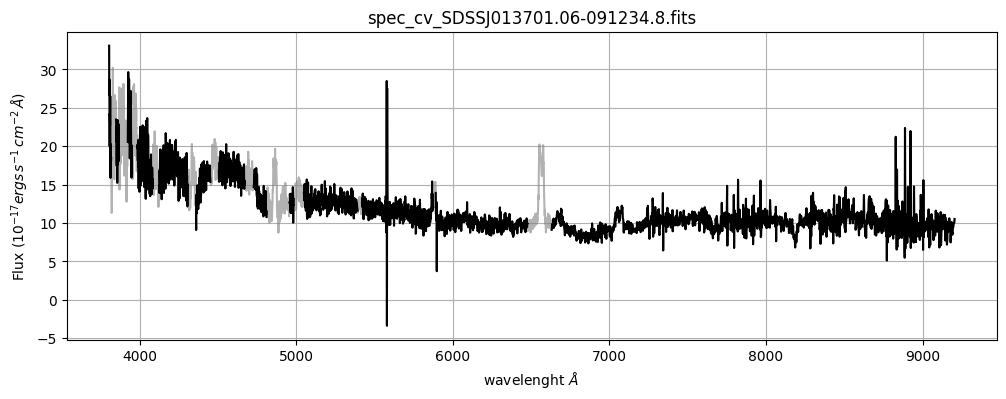

In [22]:
espectro_x= base_de_datos[4]        #problema espectro 7, lo mismo el 8
#x2= espectro_x['wavelength']
#y2= espectro_x['flux']

continuum, mask, fwhm= mask_em_lines(espectro_x)

(6530.0, 6605.0)

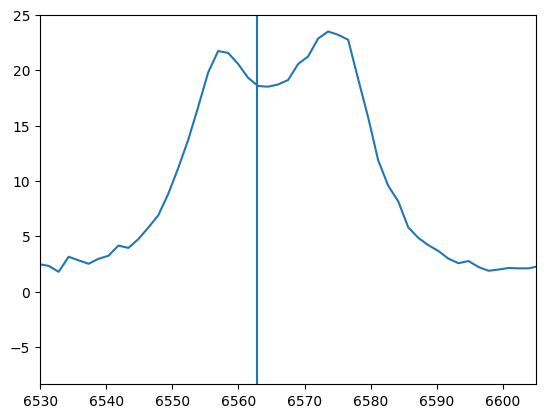

In [23]:
espectro_x= base_de_datos[7]        #problema espectro 7, lo mismo el 8
x2= espectro_x['wavelength']
y2= espectro_x['flux']

plt.plot(x2,y2)
plt.axvline(6562.8)
plt.xlim(6530,6605)

--- Iniciando Detección por Bandas (Sigma=2.5) ---
Banda Blue: Ruido Local=1.71 | Umbral=4.28
Banda Green: Ruido Local=0.78 | Umbral=1.95
Banda Red: Ruido Local=0.82 | Umbral=2.04


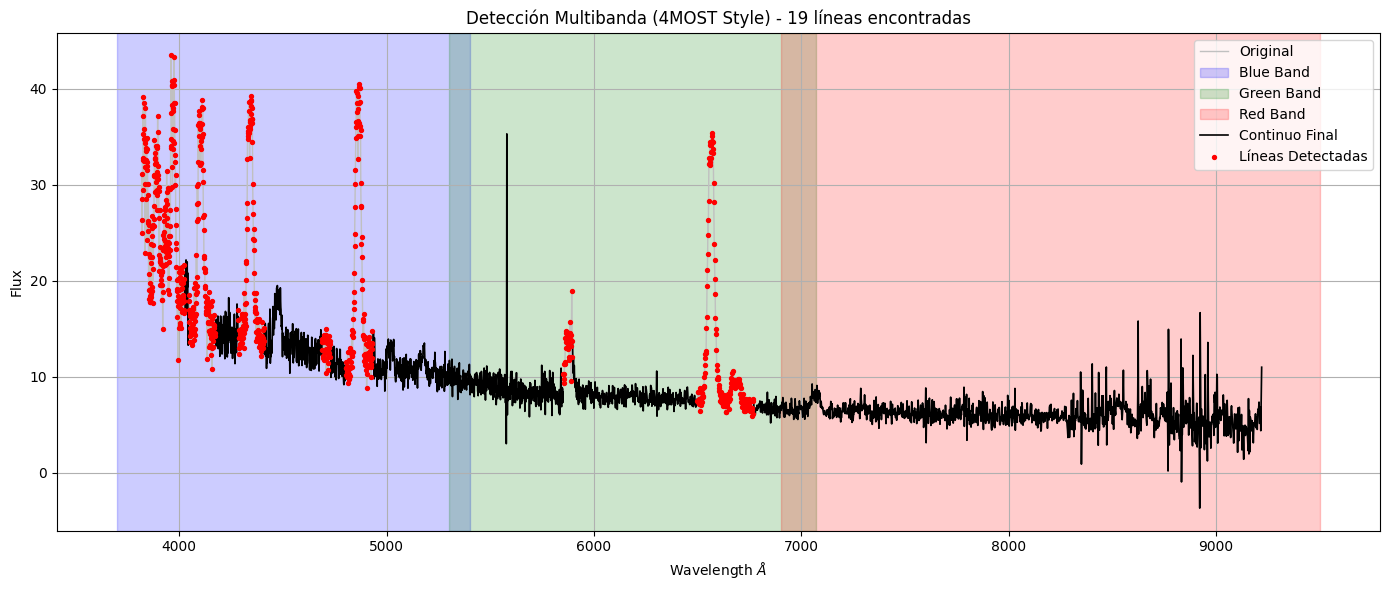

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import median_filter
import astropy.units as u

def mask_em_lines_bands(wavelength, flux, sigma=2.5): # Sigma general (se ajusta solo en cada banda)
    
    # 1. Definimos las Bandas de 4MOST (con solapamiento para seguridad)
    bands = {
        'Blue':  (3700, 5450), # Extendí un poco el límite para solapar
        'Green': (5350, 7100),
        'Red':   (6950, 9500)
    }
    
    # Diccionario de líneas (Igual que siempre)
    lines = {
        'H_alpha': 6562.8 * u.AA, 'H_beta': 4861.3 * u.AA, 'H_gamma': 4340.5 * u.AA,
        'H_delta': 4101.7 * u.AA, 'H_epsilon': 3970.1 * u.AA, 'H_zeta': 3889.1 * u.AA,
        'H_eta': 3835.4 * u.AA,
        'HeI_4471': 4471.5 * u.AA, 'HeI_4713': 4713.4 * u.AA, 'HeI_4921': 4921.9 * u.AA,
        'HeI_5015': 5015.7 * u.AA, 'HeI_5875': 5875.7 * u.AA, 'HeI_6678': 6678.2 * u.AA,
        'HeI_7065': 7065.2 * u.AA, 'HeII_4686': 4685.7 * u.AA, 'HeII_5411': 5411.5 * u.AA
    }

    # Máscara Global (empezamos con todo True)
    global_mask = np.ones(len(wavelength), dtype=bool)
    found_lines_info = []

    print(f"--- Iniciando Detección por Bandas (Sigma={sigma}) ---")

    # 2. Iteramos sobre cada Banda
    for band_name, (w_min, w_max) in bands.items():
        
        # A. Recortamos los datos a la banda actual
        # Usamos una máscara temporal para seleccionar la región
        band_idx = (wavelength >= w_min) & (wavelength <= w_max)
        
        # Si no hay datos en ese rango (ej. espectro cortado), saltamos
        if np.sum(band_idx) == 0:
            continue
            
        wave_local = wavelength[band_idx]
        flux_local = flux[band_idx]
        
        # B. Procesamiento Local (Igual que antes, pero solo con estos datos)
        # Limpieza y aplanado LOCAL
        flux_clean = flux_local.astype(float)
        continuum_rough = median_filter(flux_clean, size=101) # Filtro
        flattened = flux_local - continuum_rough
        
        # C. Cálculo de Ruido LOCAL (Aquí está la magia)
        # El H-alfa gigante en el Verde NO afecta al ruido del Azul
        mad_local = np.median(np.abs(flattened - np.median(flattened)))
        if mad_local == 0: mad_local = 1e-5 # Evitar división por cero si es plano
        robust_sigma_local = 1.4826 * mad_local
        
        threshold_local = sigma * robust_sigma_local
        
        print(f"Banda {band_name}: Ruido Local={robust_sigma_local:.2f} | Umbral={threshold_local:.2f}")

        # D. Buscar Picos en esta banda
        # Usamos prominence local
        peaks_local, properties = find_peaks(flattened, 
                                             prominence=threshold_local, 
                                             width=2) 
        
        # Calcular anchos
        widths_pixels, _, _, _ = peak_widths(flattened, peaks_local, 
                                             rel_height=0.5,
                                             prominence_data=(properties['prominences'], 
                                                              properties['left_bases'], 
                                                              properties['right_bases']))

        # E. Verificar y Enmascarar (Actualizando la máscara global)
        treshold_match = 10
        
        for p_idx, width_px in zip(peaks_local, widths_pixels):
            obs_wave = wave_local[p_idx] # Ojo: wave_local
            
            # Dispersión local
            if p_idx < len(wave_local)-1:
                disp = wave_local[p_idx + 1] - wave_local[p_idx]
            else:
                disp = wave_local[p_idx] - wave_local[p_idx-1]
                
            fwhm_ang = width_px * disp
            
            # Match con diccionario
            found = False
            for name, line in lines.items():
                if abs(obs_wave - line.value) < treshold_match:
                    found = True
                    break
            
            if found:
                # ENMASCARAR EN LA MÁSCARA GLOBAL
                # Buscamos dónde cae esta línea en el array original 'wavelength'
                mask_radius = fwhm_ang * 2.0
                bad_region_global = (wavelength > obs_wave - mask_radius) & (wavelength < obs_wave + mask_radius)
                
                # Apagamos los bits en la máscara maestra
                global_mask[bad_region_global] = False
                found_lines_info.append(obs_wave)

    # --- FINALIZAR Y GRAFICAR ---
    gaps_continuum = flux.copy()
    gaps_continuum[~global_mask] = np.nan
    
    plt.figure(figsize=(14, 6))
    plt.plot(wavelength, flux, color='silver', lw=1, label='Original')
    
    # Colorear las bandas de fondo para ver la división
    plt.axvspan(3700, 5400, color='blue', alpha=0.2, label='Blue Band')
    plt.axvspan(5300, 7070, color='green', alpha=0.2, label='Green Band')
    plt.axvspan(6900, 9500, color='red', alpha=0.2, label='Red Band')

    # Continuo limpio y puntos borrados
    plt.plot(wavelength, gaps_continuum, color='black', lw=1.2, label='Continuo Final')
    plt.scatter(wavelength[~global_mask], flux[~global_mask], color='red', s=8, zorder=5, label='Líneas Detectadas')
    
    plt.xlabel(r'Wavelength $\AA$')
    plt.ylabel('Flux')
    plt.title(f"Detección Multibanda (4MOST Style) - {len(found_lines_info)} líneas encontradas")
    plt.legend(loc='upper right')
    plt.grid('on')
    #plt.xlim(wavelength[0], wavelength[-1])
    plt.tight_layout()
    plt.show()

    return global_mask

# Uso
mask = mask_em_lines_bands(x, y, sigma=2.5)

### Armando el panel 

In [25]:

def mask_em_lines(wavelength, flux, sigma=1): 
    
    # Aseguramos usar argumentos locales
    flux_clean = flux.astype(float)
    continuum_rough = median_filter(flux_clean, size=101)
    flattened = flux - continuum_rough
    
    # MAD (Ruido robusto)
    mad = np.median(np.abs(flattened - np.median(flattened)))
    if mad == 0: mad = 1e-5 # Seguridad
    robust_sigma = 1.4826 * mad
    
    # Detección
    peaks, properties = find_peaks(flattened, 
                                   prominence=sigma*robust_sigma, 
                                   width=2) # width bajo para pillar Helio
    
    widths_pixels, _, _, _ = peak_widths(flattened, peaks, rel_height=0.5,
                                         prominence_data=(properties['prominences'], 
                                                          properties['left_bases'], 
                                                          properties['right_bases']))
    
    # Diccionario de líneas
    lines = {
        'H_alpha': 6562.8 * u.AA, 'H_beta': 4861.3 * u.AA, 'H_gamma': 4340.5 * u.AA,
        'H_delta': 4101.7 * u.AA, 'H_epsilon': 3970.1 * u.AA, 'H_zeta': 3889.1 * u.AA,
        'H_eta': 3835.4 * u.AA,
        'HeI_4471': 4471.5 * u.AA, 'HeI_4713': 4713.4 * u.AA, 'HeI_4921': 4921.9 * u.AA,
        'HeI_5015': 5015.7 * u.AA, 'HeI_5875': 5875.7 * u.AA, 'HeI_6678': 6678.2 * u.AA,
        'HeI_7065': 7065.2 * u.AA, 'HeII_4686': 4685.7 * u.AA, 'HeII_5411': 5411.5 * u.AA
    }
    
    # --- CORRECCIÓN CRÍTICA AQUÍ ---
    # Usamos len(wavelength) (el argumento), NO len(x)
    mask = np.ones(len(wavelength), dtype=bool) 
    treshold = 10 
    fwhm_list = []
    
    for peak_i, width_px in zip(peaks, widths_pixels):
        obs_wave = wavelength[peak_i]
        
        # --- CORRECCIÓN CRÍTICA AQUÍ TAMBIÉN ---
        # Usamos len(wavelength), NO len(x) para evitar IndexError en los bordes
        if peak_i < len(wavelength)-1:
            dispersion = wavelength[peak_i + 1] - wavelength[peak_i]
        else:
            dispersion = wavelength[peak_i] - wavelength[peak_i-1]
            
        fwhm_angstroms = width_px * dispersion
        fwhm_list.append(fwhm_angstroms)
        
        found_match = False
        for name, line in lines.items():
            if abs(obs_wave - line.value) < treshold:
                found_match = True
                break
        
        if found_match:
            width_mask_ang = fwhm_angstroms * 2.0
            bad_region = (wavelength > obs_wave - width_mask_ang) & (wavelength < obs_wave + width_mask_ang)
            mask[bad_region] = False
            
    # Nota: Quité el ploteo interno para que no te salgan 5 gráficos extra antes del stack
    return mask, fwhm_list

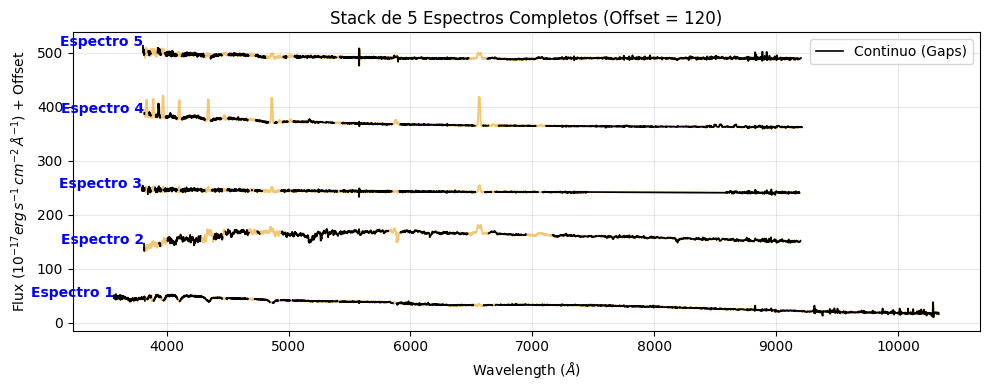

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración del gráfico
plt.figure(figsize=(10, 4)) 

# Si tu flujo va de 50 a 100, un offset de 150 separa bien las líneas
offset_step = 120 

# Iteramos sobre los primeros 5 espectros
# Usamos enumerate para tener el índice (0, 1, 2...) y el diccionario de datos a la vez
for i, data in enumerate(base_de_datos[:5]): 
    
    # 1. Extraer datos (SIN RECORTAR)
    wave = data['wavelength']
    flux = data['flux']
    
    # 2. Calcular la máscara de líneas
    # Llamamos a tu función de enmascarado con los datos completos
    # Asumo que devuelve: mask (booleano) y fwhm (valor)
    mask, _ = mask_em_lines(wave, flux)
    
    # 3. Calcular el desplazamiento vertical (Stacking)
    current_offset = i * offset_step 
    flux_shifted = flux + current_offset
    
    # 4. El TRUCO de los NaNs para el Continuo
    # Creamos una copia del flujo desplazado y ponemos NaNs donde hay líneas
    flux_gaps = flux_shifted.copy()
    flux_gaps[~mask] = np.nan 
    
    # --- GRAFICAR ---
    
    # A) Fondo gris: Muestra el espectro completo (con líneas) desplazado
    plt.plot(wave, flux_shifted, color='lightgray', alpha=0.5, lw=1)
    
    # B) Línea Negra: El continuo desplazado con huecos (gaps)
    # Etiquetamos solo el primero para no llenar la leyenda
    label_text = 'Continuo (Gaps)' if i == 0 else ""
    plt.plot(wave, flux_shifted, color='orange', alpha=0.5)
    plt.plot(wave, flux_gaps, color='black', lw=1.2, label=label_text)

    # C) Puntos Rojos: Las partes que enmascaramos (Líneas de emisión)
    # Usamos la máscara invertida [~mask] para seleccionar solo esos puntos
    #plt.scatter(wave[~mask], flux_shifted[~mask], color='red', s=5, zorder=3)
    
    # Texto para identificar cada espectro a la izquierda
    plt.text(wave[0], flux_shifted[0], f'Espectro {i+1}', 
             fontsize=10, fontweight='bold', color='blue', ha='right')

# Decoración final
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(r'Flux ($10^{-17} erg \, s^{-1} \, cm^{-2} \, \AA^{-1}$) + Offset')
plt.title(f"Stack de 5 Espectros Completos (Offset = {offset_step})")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()